In [1]:
from google.colab import files as colab_files
import os, json

for fname in ["train.json", "val.json", "test.json"]:
    for suffix in ["", " (1)", " (2)", " (3)"]:
        path = f"/content/{fname.replace('.json', suffix + '.json')}"
        if os.path.exists(path):
            os.remove(path)

print("Upload train.json, val.json, test.json from vigenere/ folder")
uploaded = colab_files.upload()

for fname in ["train.json", "val.json", "test.json"]:
    match = next((k for k in uploaded if fname.replace(".json","") in k), None)
    if match is None:
        print(f"ERROR: {fname} not found in upload")
    else:
        with open(f"/content/{fname}", "wb") as f:
            f.write(uploaded[match])
        data = json.loads(uploaded[match])
        print(f"  {fname}: {len(data)} records  OK")

SAVE_DIR = "/content/p4_outputs"
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Ready. SAVE_DIR={SAVE_DIR}")

Upload train.json, val.json, test.json from vigenere/ folder


Saving test.json to test.json
Saving train.json to train.json
Saving val.json to val.json
  train.json: 700 records  OK
  val.json: 150 records  OK
  test.json: 150 records  OK
Ready. SAVE_DIR=/content/p4_outputs


In [2]:
import subprocess
subprocess.run(['pip', 'install', '-q', 'scikit-learn'], check=True)

import math, string, time
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from torch.utils.data import Dataset, DataLoader

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

VOCAB      = list(string.ascii_lowercase + string.digits) + ['<PAD>', '<UNK>']
C2I        = {c: i for i, c in enumerate(VOCAB)}
VOCAB_SIZE = len(VOCAB)
PAD_IDX    = C2I['<PAD>']
MAX_LEN    = 512


KEY_LENGTHS = [2, 3, 6, 9, 12, 18]

KEY_MAP = {
    2  : "AB",
    3  : "CAT",
    6  : "CIPHER",
    9  : "SECRETKEY",
    12 : "CRYPTOGRAPHY",
    18 : "SECRETCRYPTOGRAPHY",
}
KEY_MAP = {k: (v * 10)[:k] for k, v in KEY_MAP.items()}

print("Key lengths:", KEY_LENGTHS)
print("Keys:", KEY_MAP)

Device: cuda
Key lengths: [2, 3, 6, 9, 12, 18]
Keys: {2: 'AB', 3: 'CAT', 6: 'CIPHER', 9: 'SECRETKEY', 12: 'CRYPTOGRAPHY', 18: 'SECRETCRYPTOGRAPHY'}


In [3]:
def vigenere_encrypt(text, key):
    key    = key.lower()
    result = []
    ki     = 0
    for c in text:
        if c in string.ascii_lowercase:
            shift = ord(key[ki % len(key)]) - ord('a')
            result.append(chr((ord(c) - ord('a') + shift) % 26 + ord('a')))
            ki += 1
        else:
            result.append(c)
    return ''.join(result)

def encode(text):
    ids = [C2I.get(c, C2I['<UNK>']) for c in text[:MAX_LEN]]
    ids += [PAD_IDX] * (MAX_LEN - len(ids))
    return torch.tensor(ids, dtype=torch.long)

def get_padding_mask(x):
    return x == PAD_IDX

class KeyLengthDataset(Dataset):
    def __init__(self, split, key):
        with open(f"/content/{split}.json", encoding="utf-8") as f:
            records = json.load(f)
        self.pairs = []
        for r in records:
            plain = ''.join(c for c in r['plaintext'].lower() if c in C2I)
            if len(plain) < 50:
                continue
            enc = vigenere_encrypt(plain, key)
            enc = ''.join(c for c in enc if c in C2I)
            self.pairs.append((encode(enc), encode(plain)))

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, i):
        return self.pairs[i]

def build_loaders(key, batch_size=32):
    return (
        DataLoader(KeyLengthDataset("train", key), batch_size=batch_size,
                   shuffle=True,  num_workers=2),
        DataLoader(KeyLengthDataset("val",   key), batch_size=batch_size,
                   shuffle=False, num_workers=2),
        DataLoader(KeyLengthDataset("test",  key), batch_size=batch_size,
                   shuffle=False, num_workers=2),
    )

print("Cipher and dataset functions ready.")

Cipher and dataset functions ready.


In [4]:
class SinusoidalPE(nn.Module):
    def __init__(self, d_model, max_len=MAX_LEN, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])

class TransformerLayer(nn.Module):
    def __init__(self, d_model=256, nhead=8, dim_ff=1024, dropout=0.1):
        super().__init__()
        self.attn  = nn.MultiheadAttention(
            d_model, nhead, dropout=dropout, batch_first=True
        )
        self.ff    = nn.Sequential(
            nn.Linear(d_model, dim_ff), nn.ReLU(), nn.Linear(dim_ff, d_model)
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.drop  = nn.Dropout(dropout)

    def forward(self, x, key_padding_mask=None):
        out, _ = self.attn(
            x, x, x, key_padding_mask=key_padding_mask, need_weights=False
        )
        x = self.norm1(x + self.drop(out))
        x = self.norm2(x + self.drop(self.ff(x)))
        return x

class TransformerDecryptor(nn.Module):
    def __init__(self, vocab_size=VOCAB_SIZE, d_model=256, nhead=8,
                 num_layers=4, dim_ff=1024, dropout=0.1):
        super().__init__()
        self.embed  = nn.Embedding(vocab_size, d_model, padding_idx=PAD_IDX)
        self.pe     = SinusoidalPE(d_model, dropout=dropout)
        self.layers = nn.ModuleList([
            TransformerLayer(d_model, nhead, dim_ff, dropout)
            for _ in range(num_layers)
        ])
        self.proj  = nn.Linear(d_model, vocab_size)
        self.scale = math.sqrt(d_model)

    def forward(self, x, key_padding_mask=None):
        x = self.pe(self.embed(x) * self.scale)
        for layer in self.layers:
            x = layer(x, key_padding_mask=key_padding_mask)
        return self.proj(x)


class LSTMDecryptor(nn.Module):
    def __init__(self, vocab_size=VOCAB_SIZE, embed_dim=128,
                 hidden=256, num_layers=2, dropout=0.1):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.lstm  = nn.LSTM(
            embed_dim, hidden, num_layers=num_layers,
            batch_first=True, bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.proj = nn.Linear(hidden * 2, vocab_size)

    def forward(self, x):
        out, _ = self.lstm(self.embed(x))
        return self.proj(out)


class CNNDecryptor(nn.Module):
    def __init__(self, vocab_size=VOCAB_SIZE, embed_dim=128,
                 num_filters=256, dropout=0.1):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.convs = nn.ModuleList([
            nn.Conv1d(embed_dim, num_filters, k, padding=k//2)
            for k in [3, 5, 7]
        ])
        self.drop = nn.Dropout(dropout)
        self.proj = nn.Linear(num_filters * 3, vocab_size)

    def forward(self, x):
        e   = self.embed(x).transpose(1, 2)
        outs = []
        for conv in self.convs:
            c = torch.relu(conv(e))
            if c.size(2) > x.size(1):
                c = c[:, :, :x.size(1)]
            elif c.size(2) < x.size(1):
                c = torch.nn.functional.pad(c, (0, x.size(1) - c.size(2)))
            outs.append(c)
        out = torch.cat(outs, dim=1).transpose(1, 2)  )
        return self.proj(self.drop(out))


class MLPDecryptor(nn.Module):
    def __init__(self, vocab_size=VOCAB_SIZE, embed_dim=128, dropout=0.1):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.net   = nn.Sequential(
            nn.Linear(embed_dim, 512), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(512, 256),       nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256, 128),       nn.ReLU(),
        )
        self.proj = nn.Linear(128, vocab_size)

    def forward(self, x):
        return self.proj(self.net(self.embed(x)))

print("All 4 models defined: Transformer, LSTM, CNN, MLP")

All 4 models defined: Transformer, LSTM, CNN, MLP


In [5]:
CRITERION = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

def train_epoch(model, loader, optimizer, is_tf):
    model.train()
    total = 0
    for src, tgt in loader:
        src, tgt = src.to(DEVICE), tgt.to(DEVICE)
        optimizer.zero_grad()
        out = (model(src, key_padding_mask=get_padding_mask(src))
               if is_tf else model(src))
        loss = CRITERION(out.reshape(-1, VOCAB_SIZE), tgt.reshape(-1))
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total += loss.item()
    return total / len(loader)

def evaluate(model, loader, is_tf):
    model.eval()
    correct = total = loss_sum = 0
    with torch.no_grad():
        for src, tgt in loader:
            src, tgt = src.to(DEVICE), tgt.to(DEVICE)
            out = (model(src, key_padding_mask=get_padding_mask(src))
                   if is_tf else model(src))
            loss_sum += CRITERION(
                out.reshape(-1, VOCAB_SIZE), tgt.reshape(-1)
            ).item()
            pred     = out.argmax(-1)
            mask     = tgt != PAD_IDX
            correct += (pred[mask] == tgt[mask]).sum().item()
            total   += mask.sum().item()
    return loss_sum / len(loader), correct / total

def run_training(name, model, is_tf, train_ldr, val_ldr, test_ldr, epochs=25):
    model   = model.to(DEVICE)
    opt     = torch.optim.Adam(model.parameters(), lr=1e-3)
    sched   = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    best_val_loss = float('inf')
    best_char_acc = 0.0

    for epoch in range(1, epochs + 1):
        train_epoch(model, train_ldr, opt, is_tf)
        val_loss, val_acc = evaluate(model, val_ldr, is_tf)
        sched.step()
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_char_acc = val_acc * 100
            torch.save(model.state_dict(),
                       os.path.join(SAVE_DIR, f"{name}.pt"))

    model.load_state_dict(
        torch.load(os.path.join(SAVE_DIR, f"{name}.pt"), map_location=DEVICE)
    )
    _, test_acc = evaluate(model, test_ldr, is_tf)
    return round(test_acc * 100, 2)

print("Training helpers ready.")

Training helpers ready.


In [6]:
RESULTS_PATH = os.path.join(SAVE_DIR, "p4_results.json")

if os.path.exists(RESULTS_PATH):
    with open(RESULTS_PATH) as f:
        all_results = json.load(f)
    print(f"Resuming — {len(all_results)} key lengths done.")
else:
    all_results = {}

MODEL_CONFIGS = {
    "transformer": (TransformerDecryptor, True),
    "lstm"       : (LSTMDecryptor,        False),
    "cnn"        : (CNNDecryptor,         False),
    "mlp"        : (MLPDecryptor,         False),
}

for kl in KEY_LENGTHS:
    key = KEY_MAP[kl]
    kl_str = str(kl)

    if kl_str in all_results:
        r = all_results[kl_str]
        print(f"Skipping key_len={kl}  "
              f"LSTM={r['lstm']}%  TF={r['transformer']}%  "
              f"CNN={r['cnn']}%  MLP={r['mlp']}%")
        continue

    print(f"\n{'='*55}")
    print(f"  Key length: {kl}  Key: '{key}'")
    print(f"{'='*55}")

    train_ldr, val_ldr, test_ldr = build_loaders(key)
    kl_results = {}

    for model_name, (ModelClass, is_tf) in MODEL_CONFIGS.items():
        t0       = time.time()
        test_acc = run_training(
            f"kl{kl}_{model_name}",
            ModelClass(),
            is_tf,
            train_ldr, val_ldr, test_ldr,
            epochs=25
        )
        elapsed = time.time() - t0
        kl_results[model_name] = test_acc
        print(f"  {model_name:<12} test_acc={test_acc:.2f}%  ({elapsed:.0f}s)")

    all_results[kl_str] = kl_results
    with open(RESULTS_PATH, "w") as f:
        json.dump(all_results, f, indent=2)
    print(f"  Saved key_len={kl}")

print("\nAll key lengths complete.")


  Key length: 2  Key: 'AB'
  transformer  test_acc=73.30%  (144s)
  lstm         test_acc=99.95%  (67s)
  cnn          test_acc=99.08%  (18s)
  mlp          test_acc=73.10%  (10s)
  Saved key_len=2

  Key length: 3  Key: 'CAT'
  transformer  test_acc=63.40%  (137s)
  lstm         test_acc=99.91%  (68s)
  cnn          test_acc=98.11%  (18s)
  mlp          test_acc=63.35%  (10s)
  Saved key_len=3

  Key length: 6  Key: 'CIPHER'
  transformer  test_acc=39.22%  (137s)
  lstm         test_acc=99.89%  (68s)
  cnn          test_acc=94.04%  (18s)
  mlp          test_acc=39.14%  (11s)
  Saved key_len=6

  Key length: 9  Key: 'SECRETKEY'
  transformer  test_acc=42.27%  (137s)
  lstm         test_acc=99.82%  (68s)
  cnn          test_acc=89.58%  (18s)
  mlp          test_acc=42.11%  (11s)
  Saved key_len=9

  Key length: 12  Key: 'CRYPTOGRAPHY'
  transformer  test_acc=34.06%  (137s)
  lstm         test_acc=99.75%  (68s)
  cnn          test_acc=85.26%  (18s)
  mlp          test_acc=33.86%  (11s)


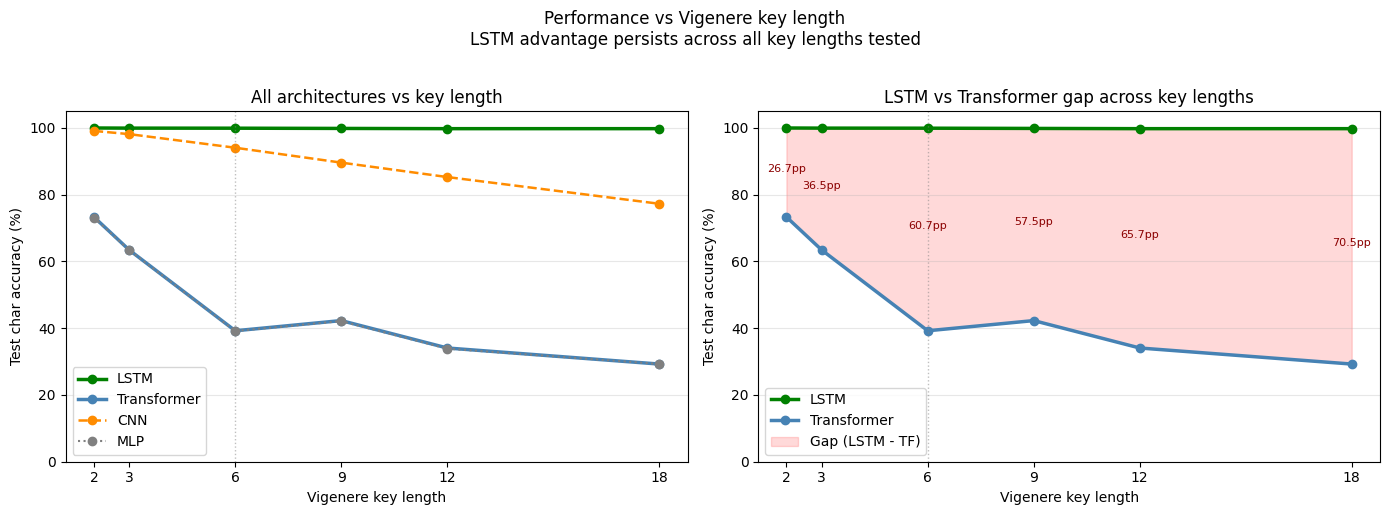

Saved: fig_p4_key_length.pdf


In [8]:
with open(RESULTS_PATH) as f:
    all_results = json.load(f)

models_to_plot = {
    "lstm"        : ("LSTM",        "green",      "-",  2.5),
    "transformer" : ("Transformer", "steelblue",  "-",  2.5),
    "cnn"         : ("CNN",         "darkorange",  "--", 1.8),
    "mlp"         : ("MLP",         "gray",        ":",  1.5),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for key, (label, color, ls, lw) in models_to_plot.items():
    ys = [all_results[str(kl)][key] for kl in KEY_LENGTHS]
    ax.plot(KEY_LENGTHS, ys, color=color, linestyle=ls,
            linewidth=lw, marker='o', markersize=6, label=label)

ax.set_xlabel("Vigenere key length")
ax.set_ylabel("Test char accuracy (%)")
ax.set_title("All architectures vs key length")
ax.set_xticks(KEY_LENGTHS)
ax.set_ylim(0, 105)
ax.legend(fontsize=10)
ax.axvline(6, color="gray", linestyle=":", linewidth=1,
           alpha=0.5, label="Paper key (len=6)")
ax.grid(axis='y', alpha=0.3)

ax = axes[1]
lstm_accs = [all_results[str(kl)]["lstm"]        for kl in KEY_LENGTHS]
tf_accs   = [all_results[str(kl)]["transformer"] for kl in KEY_LENGTHS]
gaps      = [l - t for l, t in zip(lstm_accs, tf_accs)]

ax.plot(KEY_LENGTHS, lstm_accs, color="green",     linestyle="-",
        linewidth=2.5, marker='o', markersize=6, label="LSTM")
ax.plot(KEY_LENGTHS, tf_accs,   color="steelblue", linestyle="-",
        linewidth=2.5, marker='o', markersize=6, label="Transformer")
ax.fill_between(KEY_LENGTHS, tf_accs, lstm_accs,
                alpha=0.15, color="red", label="Gap (LSTM - TF)")

for kl, g in zip(KEY_LENGTHS, gaps):
    ax.annotate(f"{g:.1f}pp",
                xy=(kl, (lstm_accs[KEY_LENGTHS.index(kl)] +
                          tf_accs[KEY_LENGTHS.index(kl)]) / 2),
                ha="center", fontsize=8, color="darkred")

ax.set_xlabel("Vigenere key length")
ax.set_ylabel("Test char accuracy (%)")
ax.set_title("LSTM vs Transformer gap across key lengths")
ax.set_xticks(KEY_LENGTHS)
ax.set_ylim(0, 105)
ax.legend(fontsize=10)
ax.axvline(6, color="gray", linestyle=":", linewidth=1, alpha=0.5)
ax.grid(axis='y', alpha=0.3)

plt.suptitle(
    "Performance vs Vigenere key length\n"
    "LSTM advantage persists across all key lengths tested",
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "fig_p4_key_length.pdf"))
plt.show()
print("Saved: fig_p4_key_length.pdf")

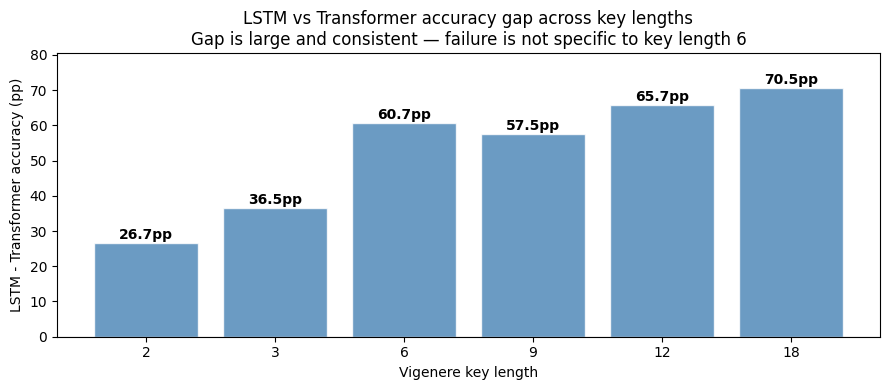

Saved: fig_p4_gap_bars.pdf


In [9]:
with open(RESULTS_PATH) as f:
    all_results = json.load(f)

gaps = [
    all_results[str(kl)]["lstm"] - all_results[str(kl)]["transformer"]
    for kl in KEY_LENGTHS
]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar([str(kl) for kl in KEY_LENGTHS], gaps,
              color="steelblue", alpha=0.8, edgecolor="white")

for bar, g in zip(bars, gaps):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f"{g:.1f}pp", ha="center", va="bottom",
            fontsize=10, fontweight="bold")

ax.set_xlabel("Vigenere key length")
ax.set_ylabel("LSTM - Transformer accuracy (pp)")
ax.set_title(
    "LSTM vs Transformer accuracy gap across key lengths\n"
    "Gap is large and consistent — failure is not specific to key length 6"
)
ax.set_ylim(0, max(gaps) + 10)
ax.axhline(0, color="gray", linewidth=0.8)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "fig_p4_gap_bars.pdf"))
plt.show()
print("Saved: fig_p4_gap_bars.pdf")

In [10]:
from google.colab import files as colab_files

for fname in ["p4_results.json",
              "fig_p4_key_length.pdf",
              "fig_p4_gap_bars.pdf"]:
    fpath = os.path.join(SAVE_DIR, fname)
    if os.path.exists(fpath):
        colab_files.download(fpath)
        print(f"Downloaded: {fname}")
    else:
        print(f"Not found: {fname}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: p4_results.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: fig_p4_key_length.pdf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: fig_p4_gap_bars.pdf
